# Fig: sketch for no overlap for consecutive beam footprints

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

from infotaxis import one_target
from infotaxis import hex_ops, utils
from infotaxis.utils_plot_hex import PLOT_ATTRS, get_echo_type_str, plot_dk_map, plot_entropy_seq

In [2]:
path_fig = Path("../figs")

In [3]:
# pm/pfa
pm = 0.005
pfa = 0.005

In [4]:
beam_axis_seq = [
    [-3, 1, +2],
    [-2, 3, -1],
    [ 0,  4, -4],
    [2, 1, -3],
    [1, -1, 0], #[1, -2, 1],
    [4, -3, -1],
    [ 0, -3,  3],
    [-3, -1,  4]
]

In [5]:
search_dict = None
param_echo = {
    str(1): {
        "pm_const": pm,
        "pfa_const": pfa,
    },
}

In [6]:
for seq in range(len(beam_axis_seq)-1):

    if seq == 0:  # initialize search
        oth = one_target.OneTargetHex(
            search_rule="infotaxis",  # search rule: "infotaxis", "MAP_future", "MAP"
            canvas_radius=5,
            beam_radius=[1],
            target_cube=(1, -2, 1),
            aim_start_cube=beam_axis_seq[0],
            param_animal= param_echo,
            param_echo= param_echo,
            search_dict=search_dict
        )

    oth.echo_value = False
    oth.update_X0()

    # Update h after updating the map
    oth.get_h_actual()
    oth.get_est_ph()

    # Assigm next beam aim and get beam coverage
    oth.aim_last_cube = beam_axis_seq[seq+1]
    oth.get_beam_coverage()

    # Update record
    oth.update_record()

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1


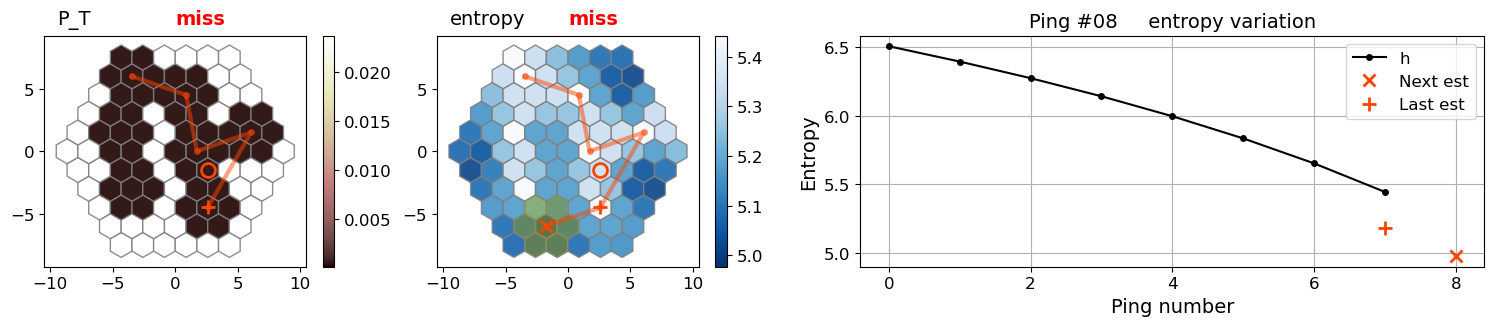

In [7]:
fig = oth.plot_latest_update()

In [8]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_loc_standalone(ax, axis_ij, sym='o', color='m', size=10):
    ax.plot(axis_ij[0], axis_ij[1],
            markersize=size,
            marker=sym,
            markerfacecolor="None",
            markeredgecolor=color,
            markeredgewidth=1.5)

In [9]:
# lifted from utils_plot_hex.py for easier control of markers
def plot_dk_map_standalone(ax, canvas_cube, canvas_vmap,
    beam_cube, env_attrs, plot_attrs, cmap="Blues_r",
    remove_cbar=False
):
    im, cbar = hex_ops.plot_hexgrids(ax,
                                     cube_array=canvas_cube,
                                     cube_color=canvas_vmap,
                                     cmap=cmap)
    ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    ax.axis('equal')

    # Beam and beam trace
    beam_plotxy = np.array([hex_ops.get_cube_plot_xy(x).squeeze()
                            for x in beam_cube])
    # beam_trace = beam_plotxy[-6:, :]    # plot last 5 beam axis loc and the next
    beam_trace = beam_plotxy    # plot all beam axis
    beam_next = beam_plotxy[-1, :]   # next beam axis loc

    ax.plot(beam_trace[:, 0], beam_trace[:, 1], marker='.',
            color=plot_attrs['symbol_color'], alpha=0.5, linewidth=2, markersize=4)
    if beam_plotxy.shape[0] > 1:  # if there was a last beam
        plot_loc_standalone(ax=ax, axis_ij=beam_plotxy[-2, :],  # plot last beam axis
                 sym='+', color=plot_attrs['symbol_color'], size=8)
    if beam_next is not None:
        plot_loc_standalone(ax=ax, axis_ij=beam_next,  # plot last beam axis
                 sym='x', color=plot_attrs['symbol_color'], size=6)

    # # Target and peg locs
    # if 'target_loc' in env_attrs:
    #     plot_loc_standalone(ax, hex_ops.get_cube_plot_xy(env_attrs['target_loc']),
    #              sym='o', color=plot_attrs['symbol_color'], size=6)  # target location

    # cbar.ax.tick_params(labelsize=plot_attrs['ticklabel_fontsize'])
    if remove_cbar:
        cbar.remove()
    else:
        pos = cbar.ax.get_position()
        cbar.ax.set_position([pos.x0 - 0.015, pos.y0, pos.width, pos.height])
        cbar.ax.set_yticks([])

In [10]:
env_attrs = dict(target_loc=oth.target_cube)

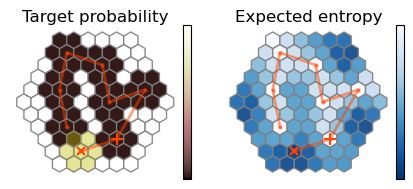

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(5.5, 2))
fig.subplots_adjust(wspace=0.001)

plot_dk_map_standalone(
    ax[0],
    canvas_cube=oth.canvas_cube,
    canvas_vmap=oth.d,
    beam_cube=oth.beam_cube_all,
    env_attrs=env_attrs,
    plot_attrs=PLOT_ATTRS,
    cmap="pink",
    remove_cbar=False
)

# Plot next beam coverage to show overlap
hex_ops.plot_hexgrids(ax[0], cube_array=oth.beam_cover_last_cube,
                      cube_color="y", gridalpha=0.4)

ax[0].set_title("Target probability", fontsize=12, pad=0)
ax[0].patch.set_visible(False)
ax[0].axis('off')

plot_dk_map_standalone(
    ax[1],
    canvas_cube=oth.canvas_cube,
    canvas_vmap=oth.h_est[1],
    beam_cube=oth.beam_cube_all,
    env_attrs=env_attrs,
    plot_attrs=PLOT_ATTRS,
    cmap="Blues_r",
    remove_cbar=False
)
ax[1].set_title("Expected entropy", fontsize=12, pad=0)
ax[1].patch.set_visible(False)
ax[1].axis('off')

plt.show()

fig.savefig(path_fig / "fig_6A_no_overlap.png", dpi=300, bbox_inches="tight")